<div style="text-align: center; font-family: Arial, sans-serif; margin-top: 50px;">
<h1 style="font-size: 36px; font-weight: bold; color: #6B20A3;">Mini-projet 4 - Méthode Monte Carlo</h1>
<h2 style="font-size: 20px; font-weight: bold; color: #6B20A3;">PHS3903</h2>
<h2 style="font-size: 20px; margin-bottom: 20px;">Philippe Clermont (2290116)</h2>
<h2 style="font-size: 20px; margin-bottom: 20px;">Arnaud Morin (2298407)</h2>
<h2 style="font-size: 20px; margin-bottom: 20px;">Sébastien Gagnon (2025393)</h2>
<h2 style="font-size: 16px; margin-bottom: 10px;">11 février 2026</h2>
<h2 style="font-size: 16px; margin-bottom: 10px;">Pr. Maksim Skorobogatiy</h2>
<h2 style="font-size: 16px; margin-bottom: 10px;">Pr. Jérémie Villeneuve</h2>
</div>


### Calcul du volume d'une $N$-sphère (20 points)

### Introduction
Une $N$-sphère de rayon $R$ est définie comme l'ensemble des points situés à une distance inférieure ou égale à $R$ de l'origine dans un espace à $N$ dimensions. Si on utilise les coordonnées cartésiennes $(x_1, x_2, \dots, x_N)$ pour décrire un point, alors ce point est situé à l'intérieur de la $N$-sphère si le critère suivant est respecté :

$$
\sum_{i=1}^{N} x_i^2 \leq R^2, \quad N=1,2,\dots
$$

Voici quelques exemples de $N$-sphères afin de clarifier ce concept :
* Une 3-sphère est la sphère habituelle en trois dimensions. Son volume est la boule dont la sphère est le contour.
* Une 2-sphère est un cercle. Son volume est l'aire du disque circonscrit par le cercle.
* Une 1-sphère est formée de deux points sur une droite qui sont situés à égale distance de l'origine. Son volume est défini comme la longueur du segment.

Ce concept peut sembler abstrait, mais il apparaît naturellement en physique statistique quand on travaille dans l'espace de phase pour étudier les propriétés d'un ensemble de $N$ particules avec une énergie fixe (ex. : gaz idéal dans une boîte fermée). 

Dans ce mini-devoir, on vous demande de calculer le volume d'une $N$-sphère de rayon unitaire $R=1$ à l'aide de la méthode de Monte-Carlo vue en classe pour le calcul d'intégrales. Le résultat est déjà connu, à savoir :

$$
V_N = \frac{\pi^{N/2}}{\Gamma\left(\frac{N}{2} + 1\right)},
$$
où $\Gamma(x)$ est la fonction gamma, ce qui vous permettra de calculer l'erreur afin d'analyser le comportement de l'algorithme.

### Choix de la méthode de Monte-Carlo

**a) [4 pts]** Expliquer pourquoi les méthodes de Monte Carlo pour l'intégration sont avantageuses pour le calcul d'intégrales à $N$ dimensions lorsque $N$ devient grand.

### Réponse a):
*(Ajoutez votre réponse ici)*

### Calcul du volume

**b) [6 pts]** Calculer le volume d'une $N$-sphère de rayon unitaire pour $N = \left\{3,6\right\}$. Pour chacune de ces $N$-sphères, calculer le résultat en faisant varier le nombre de points générés à chaque essai en utilisant les valeurs $N_{tot} = \left\{100,200,400,800,1600\right\}$. Générer 100 essais par simulation et utiliser la valeur moyenne du volume comme résultat. On vous demande donc de calculer dix valeurs de volume (cinq par $N$-sphère).

Présenter vos résultats sous forme de tableau, en fournissant une incertitude relative sur chaque résultat. Expliquer comment cette incertitude a été calculée.

### Réponse b):
*(Ajoutez votre réponse ici)*

In [51]:
# PHS3903 - Projet de simulation
# Mini-devoir 1
from tabulate import tabulate
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from scipy import interpolate
from scipy import stats
import matplotlib.ticker as mticker

# Paramètres géométriques
R = 1.0 # Rayon de la sphère (m)

# Paramètres généraux de simulation
D_val = [3,4,5,6]  # Nombre de dimensions
Ntot_val = 100 * 2 ** (np.arange(0, 5, 1))  # Nombre de points par essai
Ness = 100 # Nombre d'essais par simulation
a = 1  # Dimension de la boîte cubique dans laquelle les points aléatoires seront générés
VDth = []
# Boucle sur le nombre de simulations
ND = len(D_val)
NNtot = len(Ntot_val)

V = np.zeros((ND, NNtot+1))  # Volumes calculés pour chaque série d'essais
Vlist = V.tolist()
for i in np.arange(0, 4):
    Vlist[i][0] = [D_val[i]," Dimensions"]
V3 = []
V6 = []
D = (np.arange(3, 7, 1))
Vth = np.pi ** (D/2)/(sp.special.gamma(D/2+1)) # Volume théorique

for d in range(0, ND):
    D = D_val[d]  # Dimension
    Vtot = 2 ** D # Volume du domaine

    VDth = Vth
    for n in range(0, NNtot):
        Ntot = Ntot_val[n]  # Nombre de points

        Vind = np.zeros(Ness) # Volumes calculés pour chaque essai individuel
        Verr = np.zeros(Ness)
        erreur = np.zeros(Ness)
        for k in range(0,Ness): # Boucle sur les essais
            # Génération des nombres aléatoires (distribution uniforme)
            np.random.seed() # Initialise le générateur de nombres pseudo-aléatoires afin de ne pas toujours produire la même séquence à l'ouverture de Python...
            pts = a * np.random.uniform(low=-1, high=1, size=(Ntot, D)) # Coordonnées des points

            Nint = np.sum(np.sum(pts**2, axis=1) <= 1) 
            
            
            Vind[k] = Nint / Ntot * Vtot # Volume calculé pour cet essai
            Verr[k] = np.abs(Nint / Ntot * Vtot - Vth[d])
        ecart_type = np.std(Vind, ddof=1)
        incertitude_relative = ecart_type * 100 /(Ness**0.5 * np.mean(Vind))
        Vlist[d][n+1] = [np.mean(Vind), incertitude_relative] # Volume moyenné sur l'ensemble des essais
        if D == 3:
            V3.append(np.mean(Verr))
        if D == 6:
            V6.append(np.mean(Verr))
header = []
header.append("Dimensions")
for i in Ntot_val:
    header.append(f"N = {i}")
header.append("Valeur théorique")
j=0
Table = []
for m in Vlist:
    vecteur = []
    h = 0
    for value in m:
        if isinstance(value[1], str):
            vecteur.append(f"{value[0]:.4g} {value[1]}") 
        else:    
            vecteur.append(f"{value[0]:.4g}{u"\u00B1"}{value[1]:.3g}%")   
    Table.append(vecteur) 
for i in Table:
    i.append(VDth[j])
    j+=1

print(tabulate(Table, headers = header, tablefmt="github"))

| Dimensions    | N = 100     | N = 200      | N = 400      | N = 800      | N = 1600     |   Valeur théorique |
|---------------|-------------|--------------|--------------|--------------|--------------|--------------------|
| 3  Dimensions | 4.256±1.02% | 4.182±0.624% | 4.198±0.497% | 4.184±0.344% | 4.172±0.232% |            4.18879 |
| 4  Dimensions | 4.878±1.57% | 4.955±1.06%  | 4.921±0.776% | 4.875±0.578% | 4.921±0.354% |            4.9348  |
| 5  Dimensions | 5.27±2.42%  | 5.264±1.6%   | 5.258±1.16%  | 5.262±0.693% | 5.235±0.585% |            5.26379 |
| 6  Dimensions | 5.101±3.55% | 5.283±2.56%  | 5.088±1.61%  | 5.131±1.21%  | 5.228±0.839% |            5.16771 |


### Réponse c):
L'incertitude relative à été obtenue en prenant l'écart-type de la distribution obtenue et en la divisant par la racine du nombre d'essais exécutés (Ness) et la valeur moyenne.

### Analyse de l'erreur

**c) [4 pts]** À l'aide des résultats précédents obtenus, tracer un graphique de l'erreur relative $E$ sur le volume calculé en fonction de $N_{tot}$ pour chaque $N$-sphère. (Vous tracerez donc deux séries de données sur le même graphique.) Utiliser une échelle qui permet de représenter facilement le comportement de l'erreur.

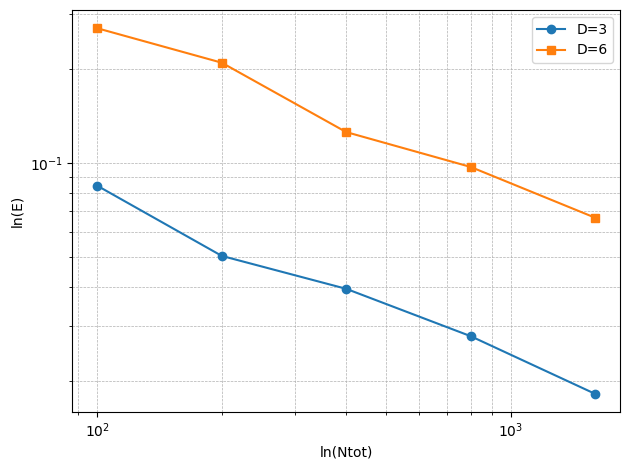

In [55]:
plt.figure()
erreur3D = V3/Vth[0]
erreur6D = V6/Vth[3]

plt.loglog(np.array(Ntot_val), erreur3D, 'o-', label=f"D=3")
plt.loglog(np.array(Ntot_val), erreur6D, 's-', label=f"D=6")

plt.xlabel("ln(Ntot)")
plt.ylabel("ln(E)")

plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

### Réponse c):
Soit le graphique généré de l'erreur en échelle logarithmique permet de distinguer la relation linéaire de ces logarithmes.

**d) [2 pts]** Déterminer le comportement de l'erreur relative en calculant l'exposant $p$ tel que :

$$
E = O(N_{tot}^p)
$$
pour chacune des deux $N$-sphères.

In [57]:
logN = np.log(Ntot_val)
logE3 = np.log(erreur3D)
logE6 = np.log(erreur6D)

p3, b3 = np.polyfit(logN, logE3, 1)
p6, b6 = np.polyfit(logN, logE6, 1)

print(f"Exposant p pour D=3  : {p3:.3f}")
print(f"Exposant p pour D=6  : {p6:.3f}")

Exposant p pour D=3  : -0.530
Exposant p pour D=6  : -0.515


**e) [4 pts]** Discuter des points suivants :
* Comment les valeurs de $p$ calculées se comparent-t-elle aux valeurs théoriques attendues ?
* La précision des résultats obtenus est-elle la même pour la 3-sphère et pour la 6-sphère ?
* Comment l'incertitude relative calculée en (b) se compare-t-elle à l'erreur relative ?

### Réponse e):
Les valeurs de *(p)* calculées, se comparent bien aux valeurs théoriques attendues de -0,5. Soit de 1/(racine de Ntot)

La précision des résultats obtenus n'est pas la même pour les deux sphères, car on ajoute des variables au système ce qui viens réduire la précision de l'évalution probabiliste.

L'erreur relative est plus grande que l'incertitude relative d'environ le facteur racine de Ness, car l'incertitude est l'écart-type diviser par la racine de Ness et la moyenne alors que l'erreur est l'écart-type sur la valeur théorique (moyenne).

In [58]:
print (f"L'erreur relative pour 3D est de {np.array(erreur3D)*100}%")

L'erreur relative pour 3D est de [8.44157818 5.02597175 3.93966248 2.77588035 1.81205581]%
